# Policy rollouts

## Imports & global configurations

In [1]:
import sys
sys.path.append("..")

from source.policy import HeuristicPolicy, NeuralPolicy
from source.simulation import rollout_trajectory, sample_initial_state
from source.stochastic_processes import make_price_function
from source.system import SystemParams
from source.utils import read_csv
from source.plotting import *
from source.diagnostics import check_energy_balance

import torch

import matplotlib.pyplot as plt
plt.style.use("../styles/paper.mplstyle")

In [2]:
global_seed = 123

device = torch.device("cpu")
batch_size = 1000

params = SystemParams()

S0 = sample_initial_state(
    batch_size=batch_size,
    params=params,
    device=device,
    seed=global_seed
)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

results = {}

## Heuristic Policy

In [4]:
next_price_function = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

policy = HeuristicPolicy()

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_function,
    lambda_cost=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

results["heuristic"] = history

In [5]:
check_energy_balance(history, params.dt)

{'max_abs_error': 0.0,
 'mean_abs_error': 0.0,
 'mean_Ub': 34.942161560058594,
 'max_Ub': 432.0}

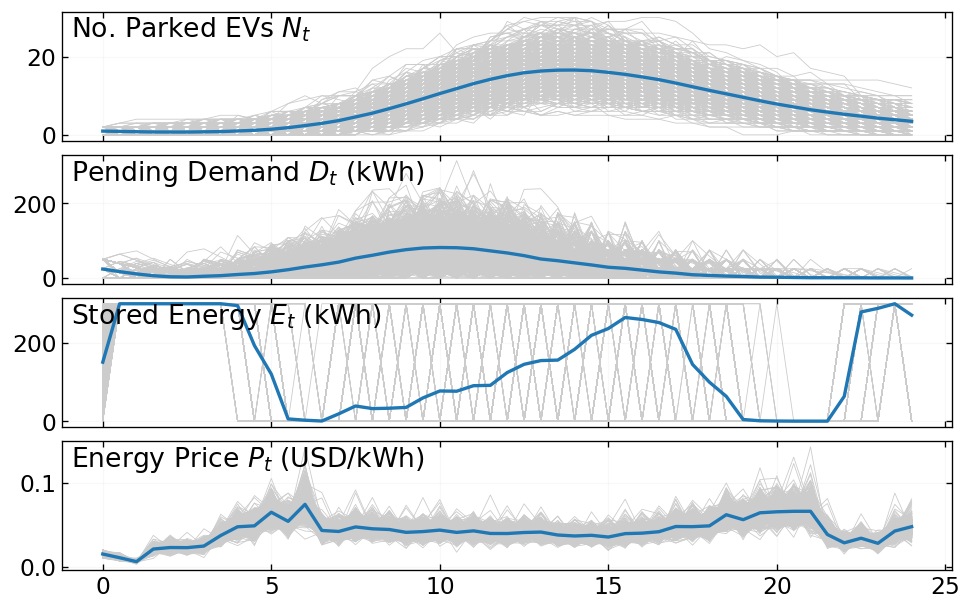

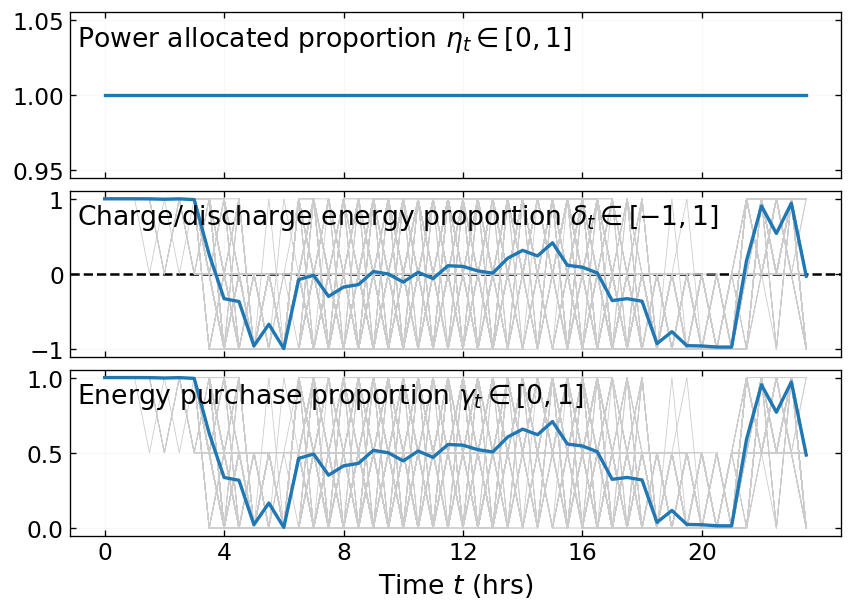

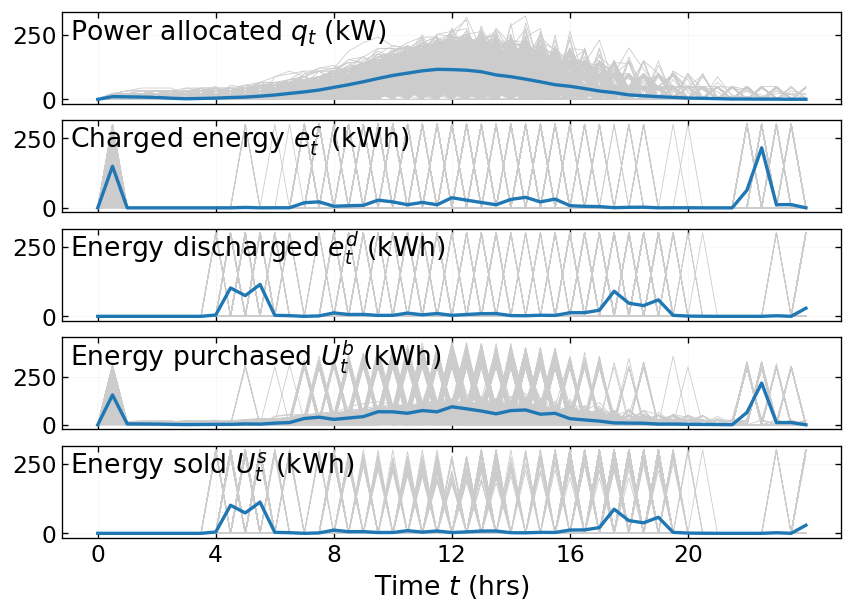

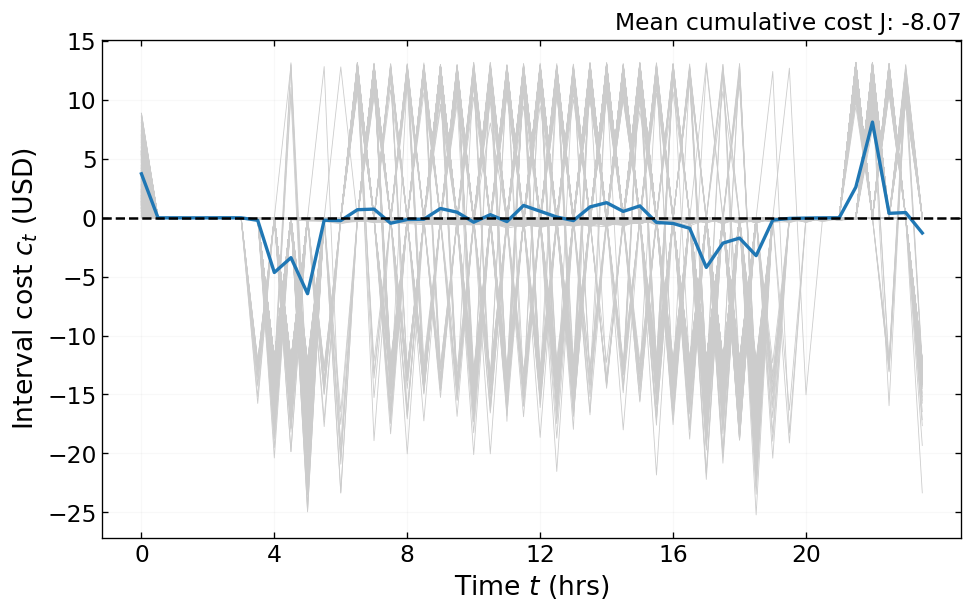

In [6]:
plot_state_trajectories(
    history, save_path="../figures/heuristic_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/heuristic_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/heuristic_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/heuristic_policy/cost.pdf"
)

## Untrained Neural Policy 

In [8]:
from pathlib import Path
import torch

In [9]:
torch.manual_seed(global_seed)
policy = NeuralPolicy()

checkpoint_dir = Path("../checkpoints/policies")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "seed": global_seed,
        "state_dict": policy.state_dict(),
        "description": "Fixed untrained policy baseline"
    },
    checkpoint_dir / "untrained_policy.pt"
)

checkpoint = torch.load(
    "../checkpoints/policies/untrained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["state_dict"])
policy.eval()

next_price_function = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_function,
    lambda_cost=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

results["untrained"] = history

In [10]:
check_energy_balance(history, params.dt)

{'max_abs_error': 3.814697265625e-06,
 'mean_abs_error': 1.1861324367146153e-08,
 'mean_Ub': 19.808984756469727,
 'max_Ub': 155.3538360595703}

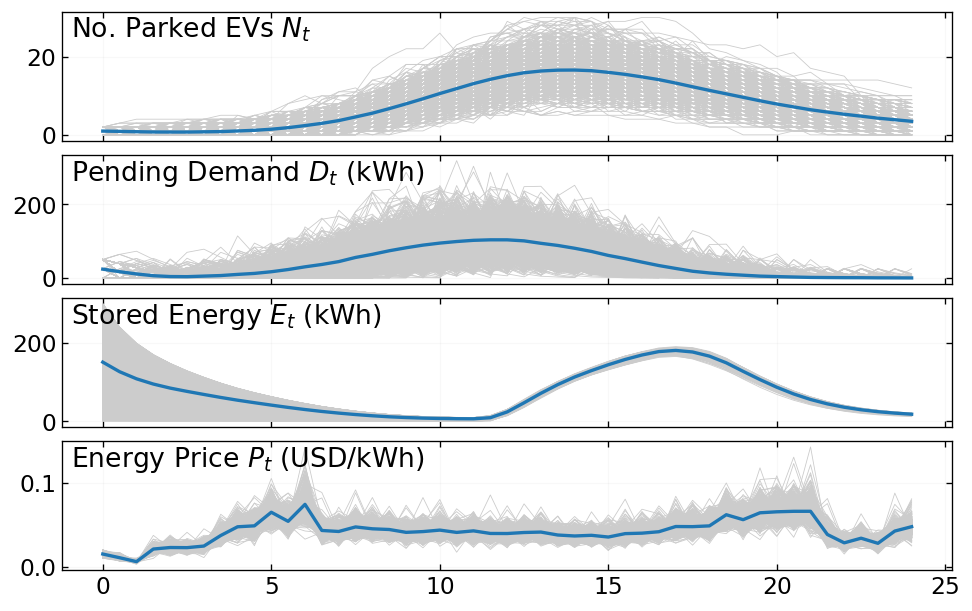

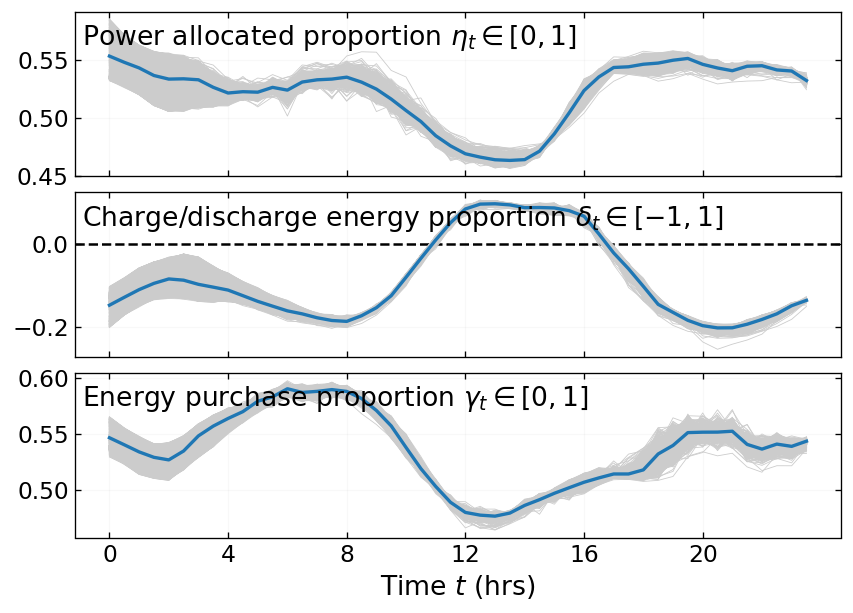

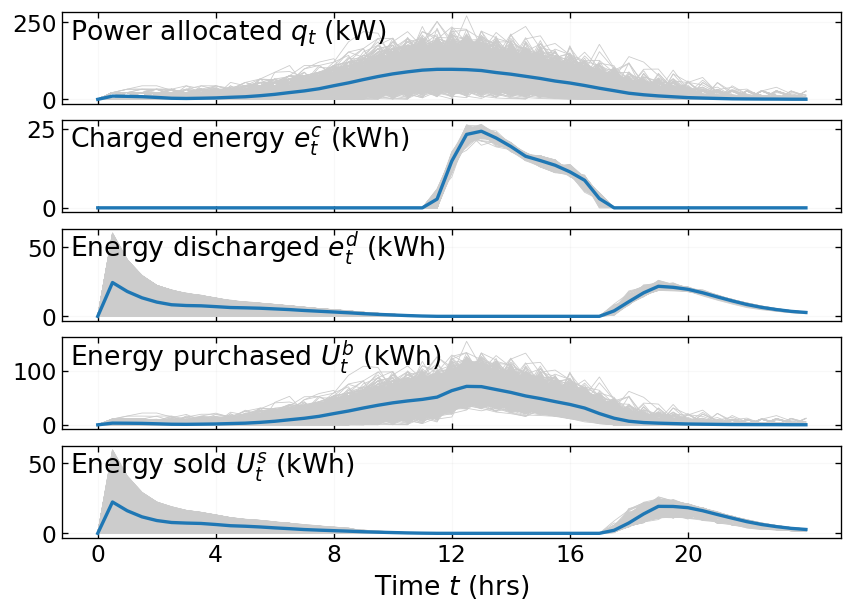

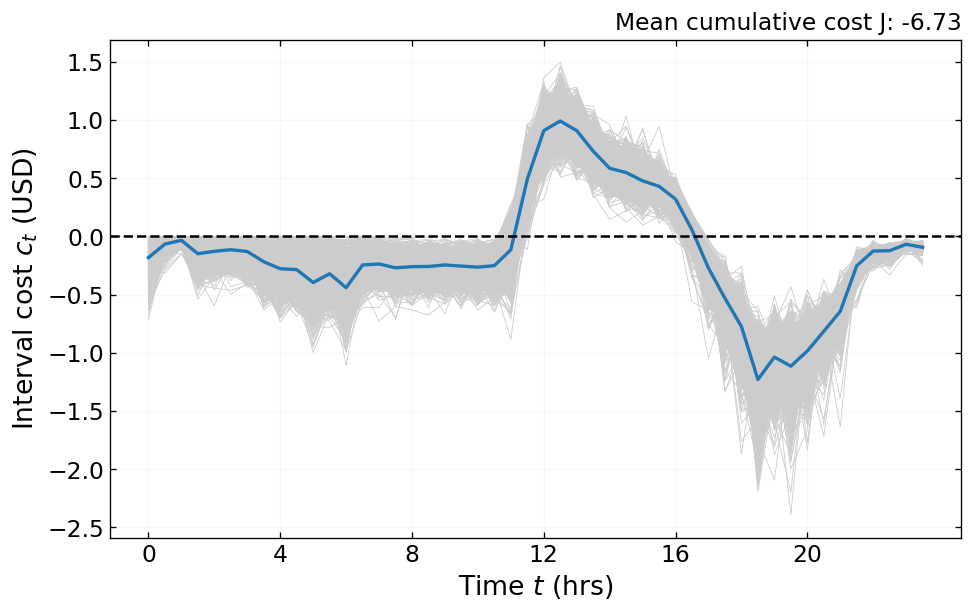

In [11]:
plot_state_trajectories(
    history, save_path="../figures/untrained_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/untrained_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/untrained_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/untrained_policy/cost.pdf"
)

## Trained Neural Policy

In [12]:
from source.training import train_net

EPOCHS = 1000

S0_single = torch.tensor([[0., 0., 100., 0.01]], device=device)

checkpoint = torch.load(
    "../checkpoints/policies/untrained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["state_dict"])

optimizer = torch.optim.AdamW(
    policy.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

res = train_net(
    policy=policy,
    optimizer=optimizer,
    device=device,
    params=params,
    S0_single=S0_single,
    endog_history=price_history,
    future_endog=future_price,
    epochs=EPOCHS,
    batch_size=batch_size,
    verbose=True,
    seed_base=global_seed
)

[050] J_train=-9.4682 | J_eval(det)=-9.7222
[100] J_train=-12.9618 | J_eval(det)=-12.9657
[150] J_train=-14.4694 | J_eval(det)=-14.2639
[200] J_train=-17.3172 | J_eval(det)=-16.7000
[250] J_train=-19.1732 | J_eval(det)=-17.9740
[300] J_train=-20.7378 | J_eval(det)=-18.8588
[350] J_train=-21.8021 | J_eval(det)=-19.5487
[400] J_train=-23.1731 | J_eval(det)=-20.1940
[450] J_train=-24.1983 | J_eval(det)=-20.9799
[500] J_train=-25.3548 | J_eval(det)=-21.7083
[550] J_train=-25.8399 | J_eval(det)=-22.1439
[600] J_train=-26.0871 | J_eval(det)=-22.2686
[650] J_train=-26.6671 | J_eval(det)=-22.2942
[700] J_train=-26.9475 | J_eval(det)=-22.4957
[750] J_train=-26.9691 | J_eval(det)=-22.5961
[800] J_train=-26.8747 | J_eval(det)=-22.7431
[850] J_train=-27.0653 | J_eval(det)=-22.7422
[900] J_train=-27.4254 | J_eval(det)=-22.7819
[950] J_train=-27.2867 | J_eval(det)=-22.8708
[1000] J_train=-27.5232 | J_eval(det)=-22.8744

Training ready in 491.1s. Epoch: 996. Best J=-27.9179


In [14]:
from pathlib import Path
import torch

checkpoint_dir = Path("../checkpoints/policies")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint = {
    "best_J": res["best_J"],
    "policy_state_dict": res["best_state"],
    "J_train_hist": res["J_train_hist"],
    "J_eval_hist": res["J_eval_hist"],
    "seed_base": global_seed,
    "epochs": EPOCHS,
    "batch_size": batch_size,
    "lr": 5e-4,
    "weight_decay": 1e-5,
}

torch.save(checkpoint, checkpoint_dir / "trained_policy.pt")

In [15]:
checkpoint = torch.load(
    "../checkpoints/policies/trained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["policy_state_dict"])
policy.eval()

next_price_fn = make_price_function(price_history, future_price, params)

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_fn,
    stochastic=True,
    alpha_grid=0.0,
    lambda_cost=0.0,
    seed=global_seed,
    device=device,
)

results["trained"] = history

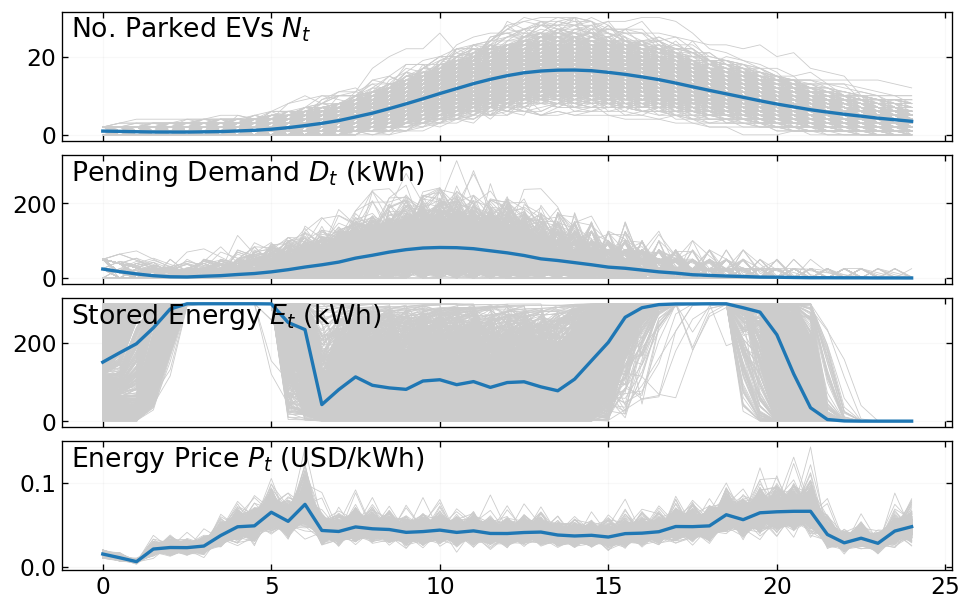

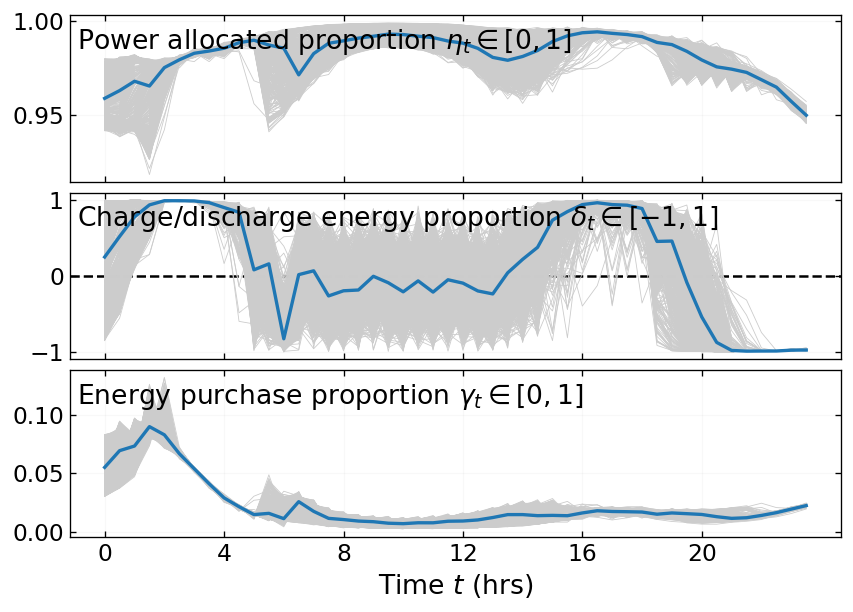

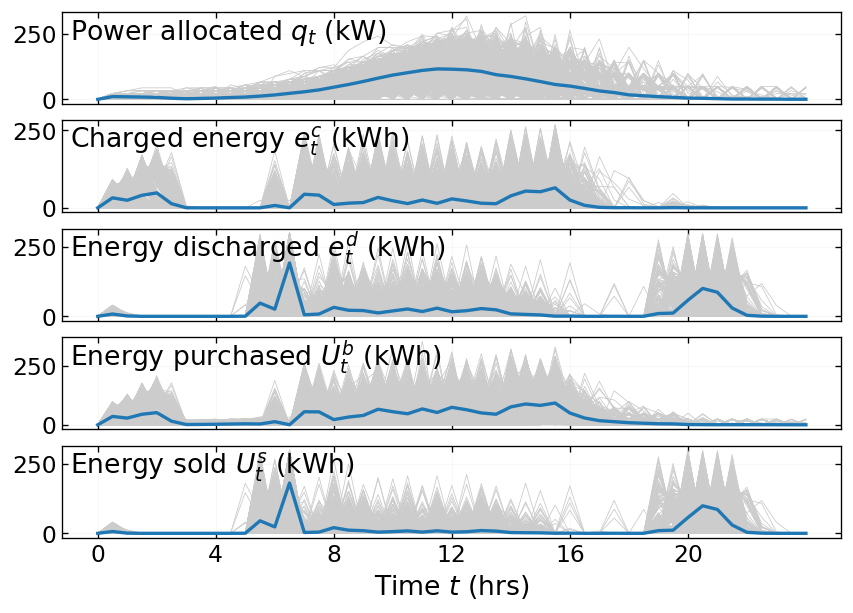

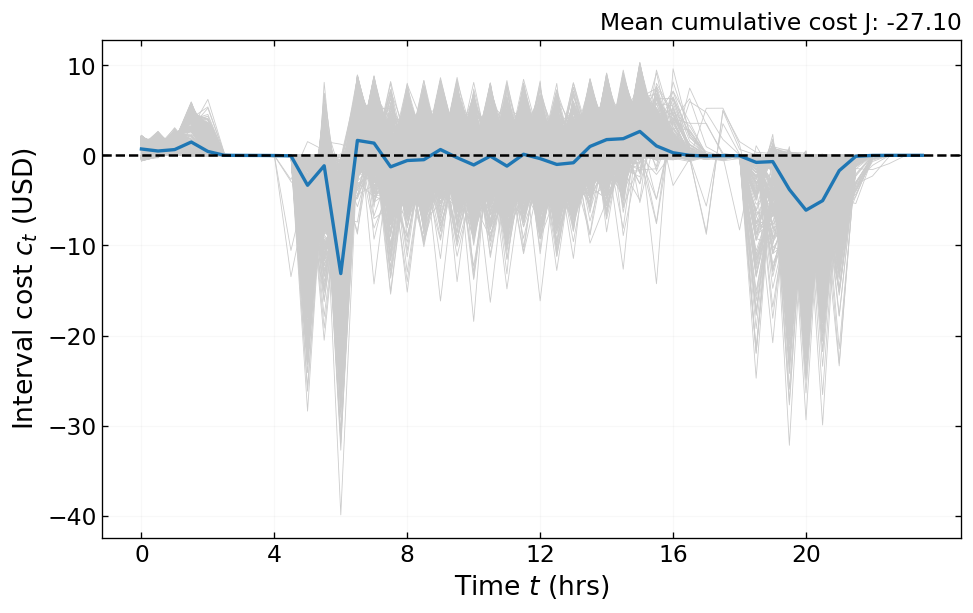

In [16]:
plot_state_trajectories(
    history, save_path="../figures/trained_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/trained_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/trained_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/trained_policy/cost.pdf"
)

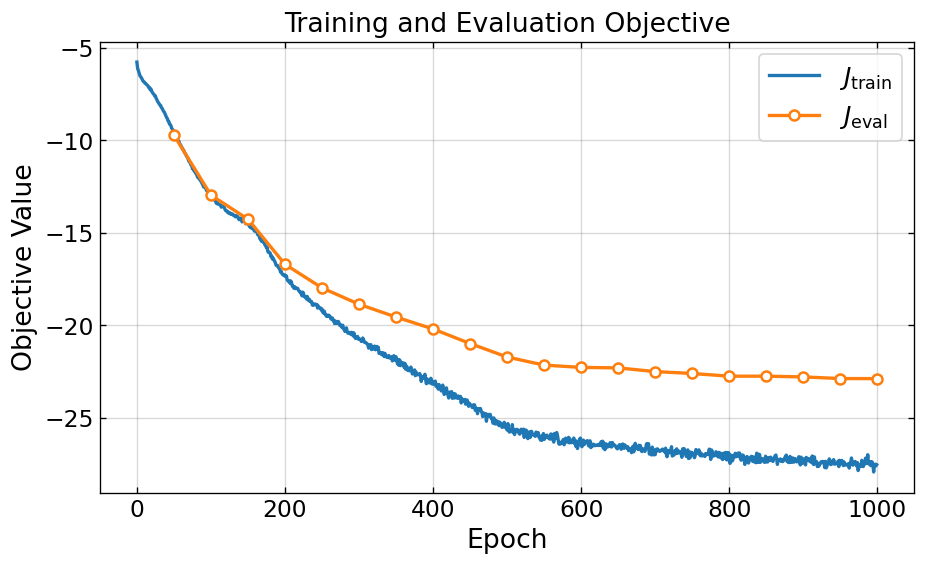

In [27]:
import os

SAVE_DIR = "../figures/trained_policy"
os.makedirs(SAVE_DIR, exist_ok=True)

J_train = checkpoint["J_train_hist"]
J_eval = checkpoint["J_eval_hist"]

eval_epochs = np.arange(
    len(J_train) // len(J_eval),
    len(J_train) + 1,
    len(J_train) // len(J_eval)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    J_train,
    linewidth=2,
    label=r"$J_{\mathrm{train}}$"
)

ax.plot(
    eval_epochs,
    J_eval,
    marker="o",
    markerfacecolor="white",
    markeredgewidth=1.5,
    linewidth=2,
    label=r"$J_{\mathrm{eval}}$"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Objective Value")
ax.set_title("Training and Evaluation Objective")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    os.path.join(
        SAVE_DIR,
        "training_curve.pdf"
    ),
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(
        SAVE_DIR,
        "training_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Stochastic Scenario Verification

In [17]:
print("\n" + "="*60)
print("ARRIVALS (arrival)")
print("="*60)

same = torch.allclose(
    results["untrained"]["arrival"],
    results["heuristic"]["arrival"]
)
max_diff = (
    results["untrained"]["arrival"]
    - results["heuristic"]["arrival"]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["arrival"],
    results["trained"]["arrival"]
)
max_diff = (
    results["untrained"]["arrival"]
    - results["trained"]["arrival"]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")


print("\n" + "="*60)
print("DEPARTURES (departure)")
print("="*60)

same = torch.allclose(
    results["untrained"]["departure"],
    results["heuristic"]["departure"]
)
max_diff = (
    results["untrained"]["departure"]
    - results["heuristic"]["departure"]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["departure"],
    results["trained"]["departure"]
)
max_diff = (
    results["untrained"]["departure"]
    - results["trained"]["departure"]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")


print("\n" + "="*60)
print("PRICE (state[..., 3])")
print("="*60)

same = torch.allclose(
    results["untrained"]["state"][..., 3],
    results["heuristic"]["state"][..., 3]
)
max_diff = (
    results["untrained"]["state"][..., 3]
    - results["heuristic"]["state"][..., 3]
).abs().max().item()

print(f"Untrained vs heuristic : {same}")
print(f"Max difference         : {max_diff:.6f}")

same = torch.allclose(
    results["untrained"]["state"][..., 3],
    results["trained"]["state"][..., 3]
)
max_diff = (
    results["untrained"]["state"][..., 3]
    - results["trained"]["state"][..., 3]
).abs().max().item()

print(f"Untrained vs Trained   : {same}")
print(f"Max difference         : {max_diff:.6f}")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)

A_same = torch.allclose(
    results["untrained"]["arrival"],
    results["trained"]["arrival"]
)

B_same = torch.allclose(
    results["untrained"]["departure"],
    results["trained"]["departure"]
)

P_same = torch.allclose(
    results["untrained"]["state"][..., 3],
    results["trained"]["state"][..., 3]
)

if A_same and B_same and P_same:
    print("✅ Same stochastic scenario across policies.")
else:
    print("❌ Stochastic processes differ between policies.")
    print(f"   Arrivals equal   : {A_same}")
    print(f"   Departures equal : {B_same}")
    print(f"   Prices equal     : {P_same}")


ARRIVALS (arrival)
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : True
Max difference         : 0.000000

DEPARTURES (departure)
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : True
Max difference         : 0.000000

PRICE (state[..., 3])
Untrained vs heuristic : True
Max difference         : 0.000000
Untrained vs Trained   : True
Max difference         : 0.000000

SUMMARY
✅ Same stochastic scenario across policies.


In [18]:
rollout_dir = Path("../checkpoints/rollouts")
rollout_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    results,
    rollout_dir / "policy_comparison.pt"
)

# Policy comparison

In [19]:
results = torch.load(
    "../checkpoints/rollouts/policy_comparison.pt",
    map_location=device
)

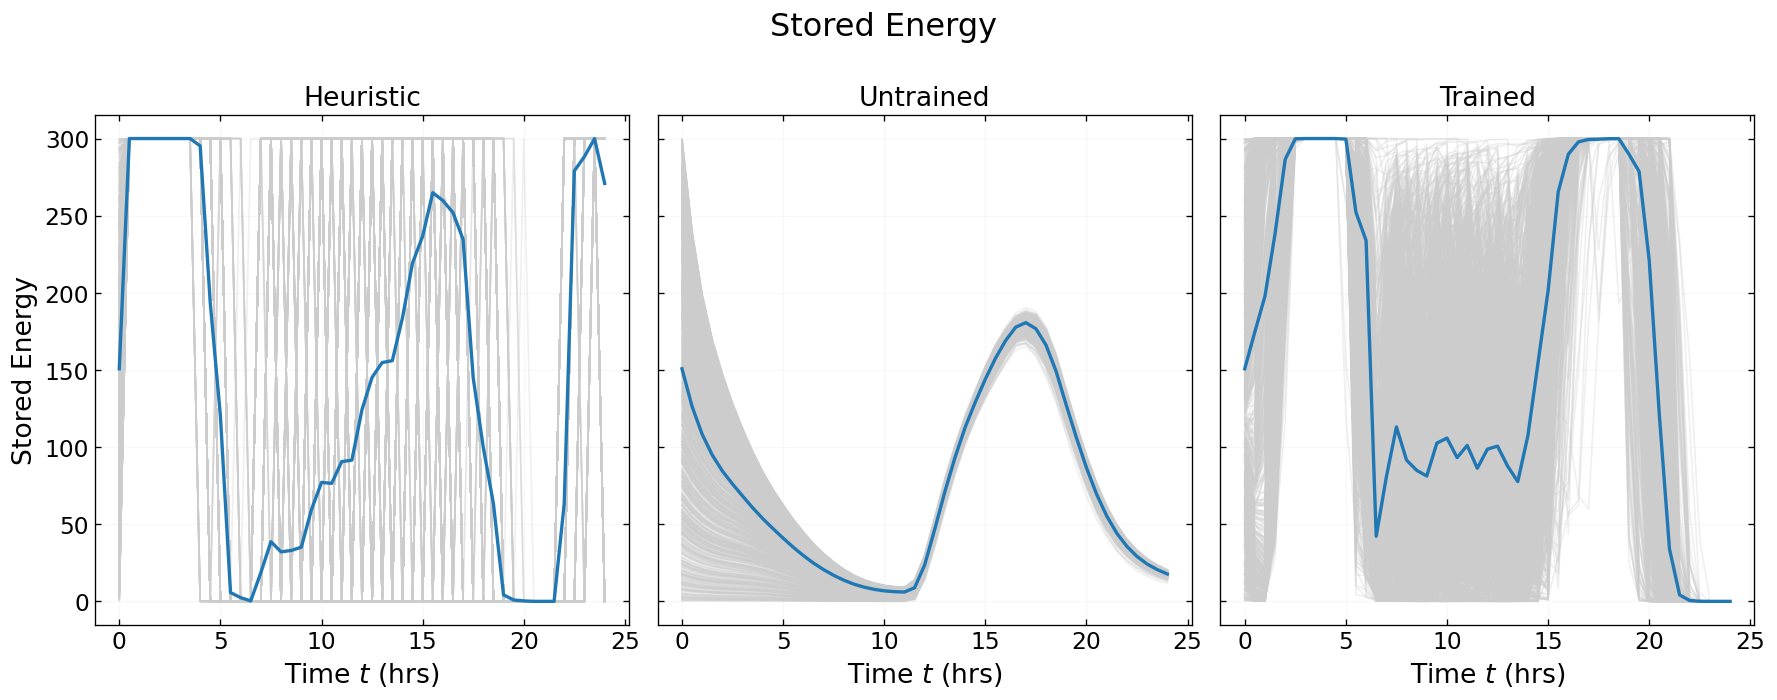

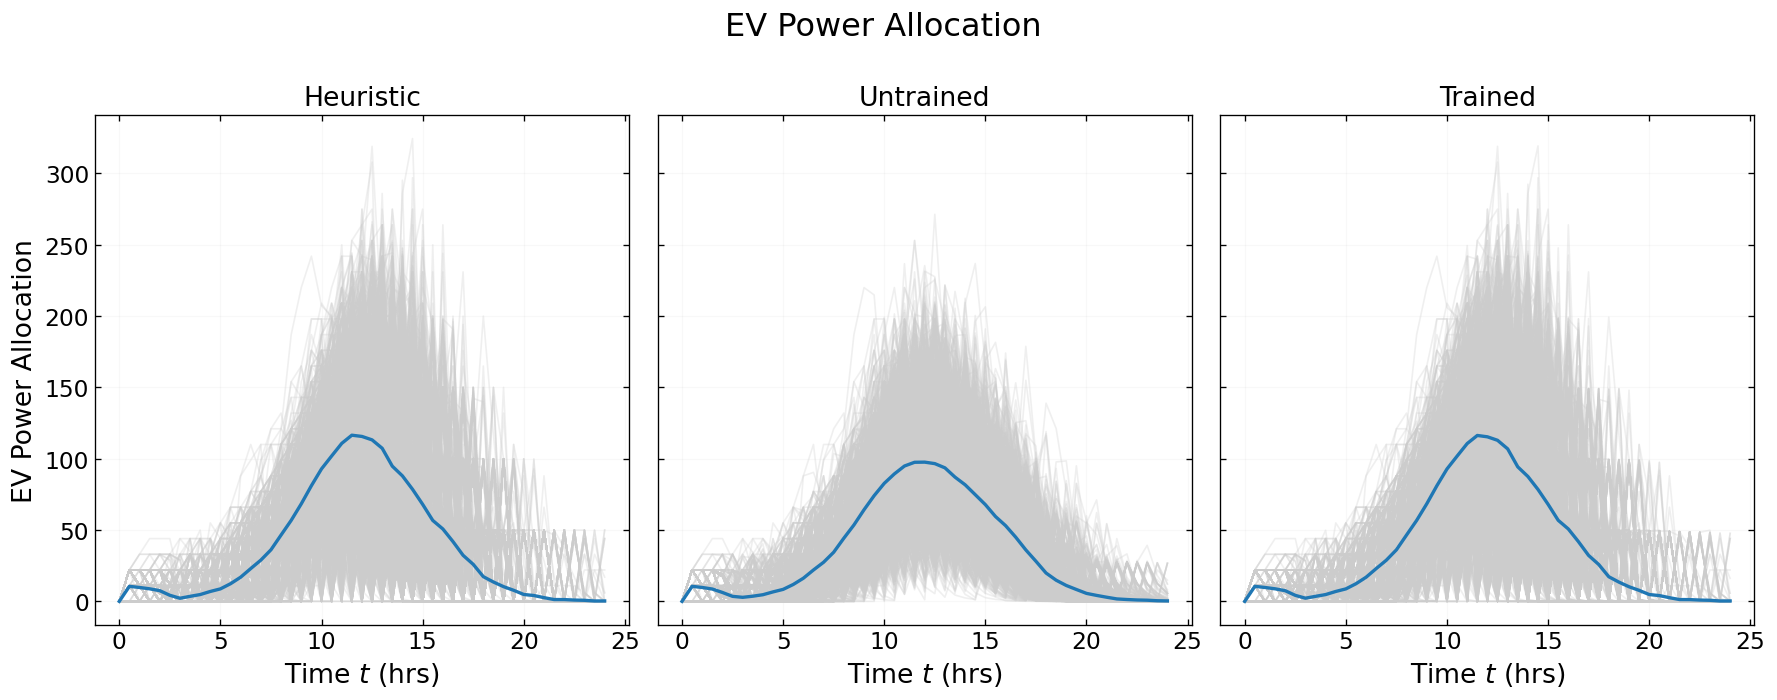

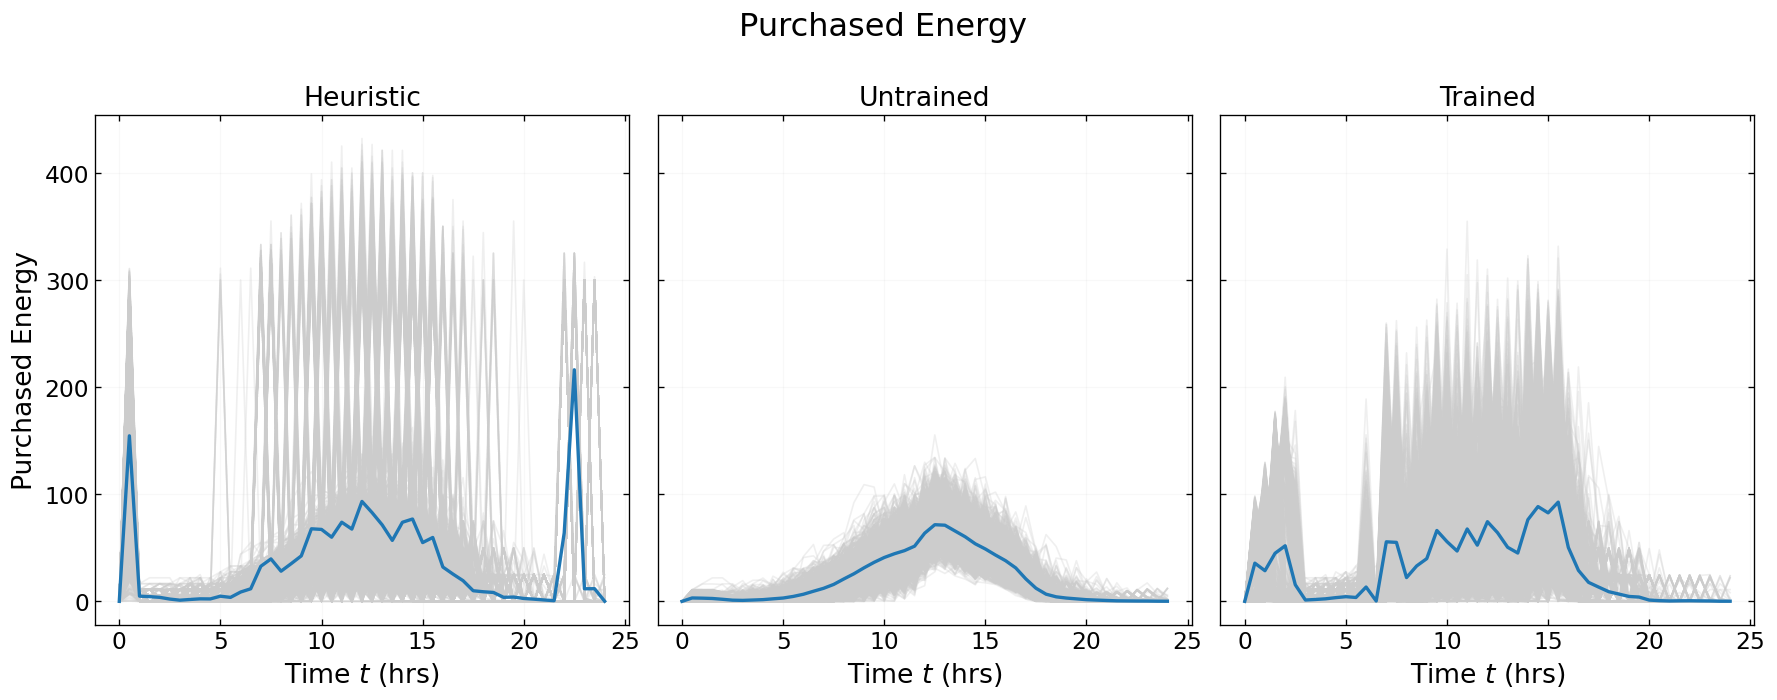

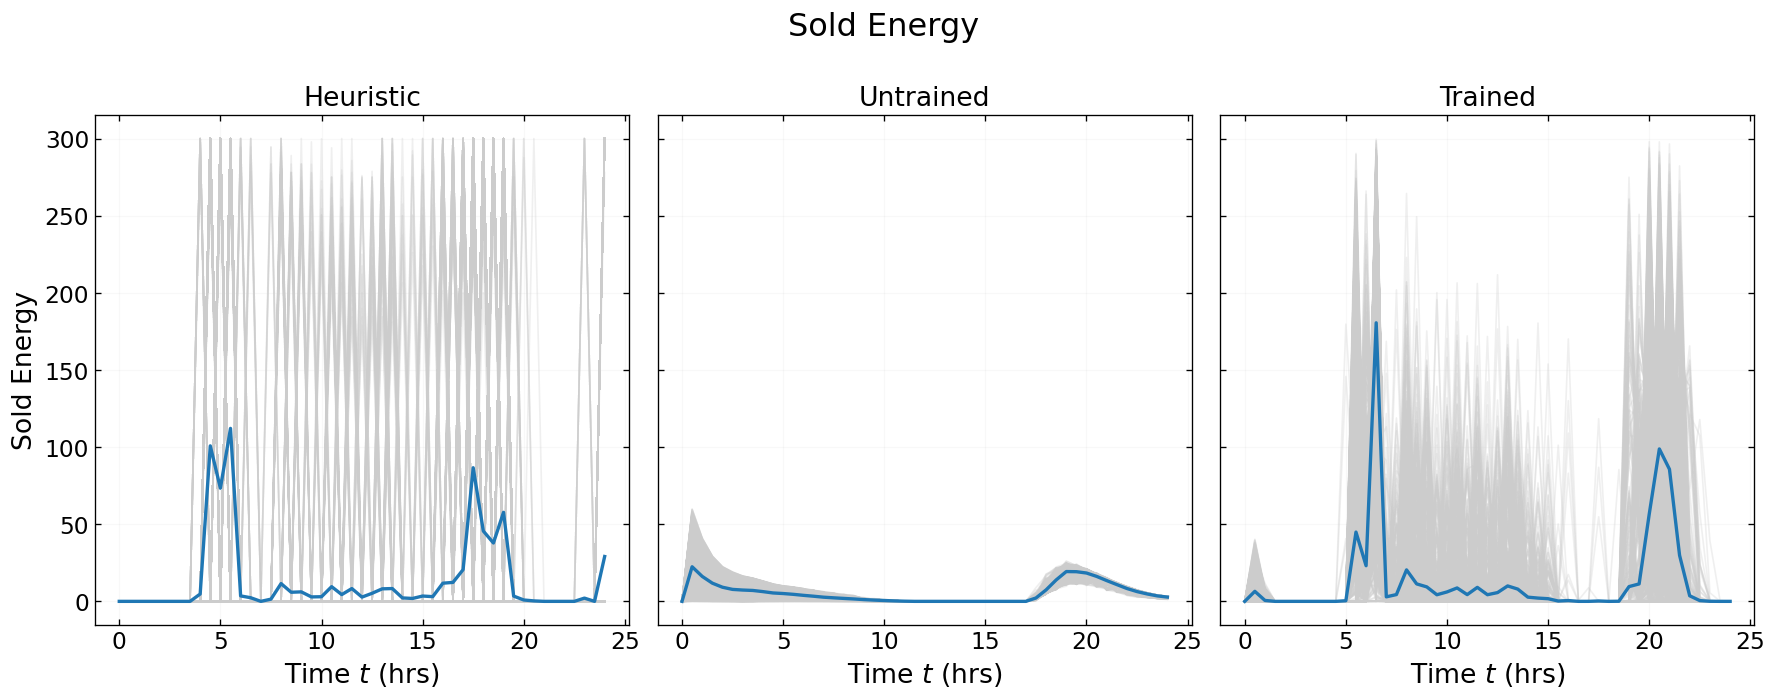

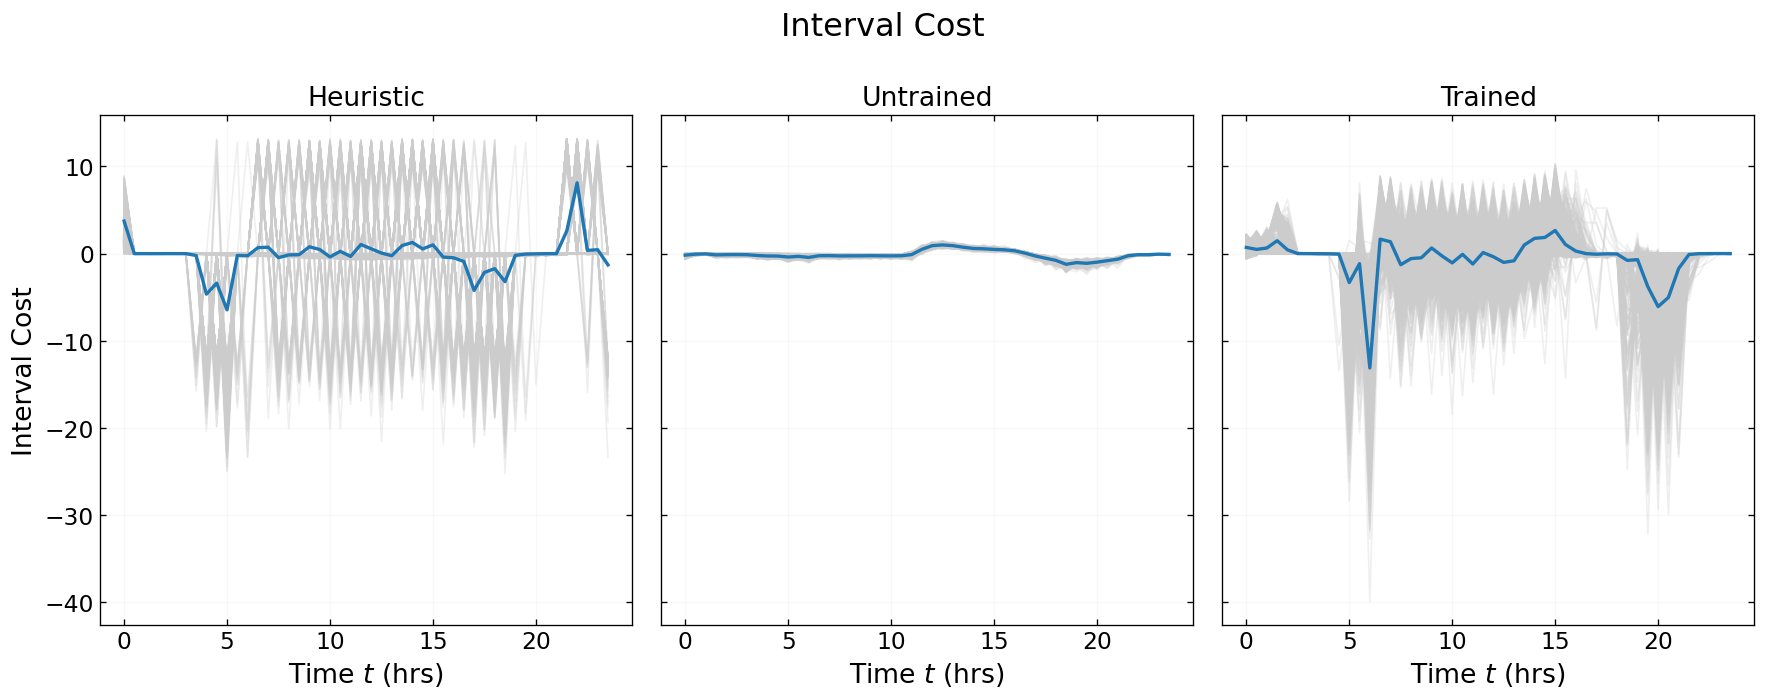

(<Figure size 1800x720 with 3 Axes>,
 array([<Axes: title={'center': 'Heuristic'}, xlabel='Time $t$ (hrs)', ylabel='Interval Cost'>,
        <Axes: title={'center': 'Untrained'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'center': 'Trained'}, xlabel='Time $t$ (hrs)'>],
       dtype=object))

In [20]:
plot_variable_across_policies(
    results,
    "E",
    "Stored Energy",
    "../figures/policy_comparison/stored_energy.pdf"
)

plot_variable_across_policies(
    results,
    "q",
    "EV Power Allocation",
    "../figures/policy_comparison/ev_power_allocation.pdf"
)

plot_variable_across_policies(
    results,
    "Ub",
    "Purchased Energy",
    "../figures/policy_comparison/purchased_energy.pdf"
)

plot_variable_across_policies(
    results,
    "Us",
    "Sold Energy",
    "../figures/policy_comparison/sold_energy.pdf"
)

plot_variable_across_policies(
    results,
    "c",
    "Interval Cost",
    "../figures/policy_comparison/interval_cost.pdf"
)

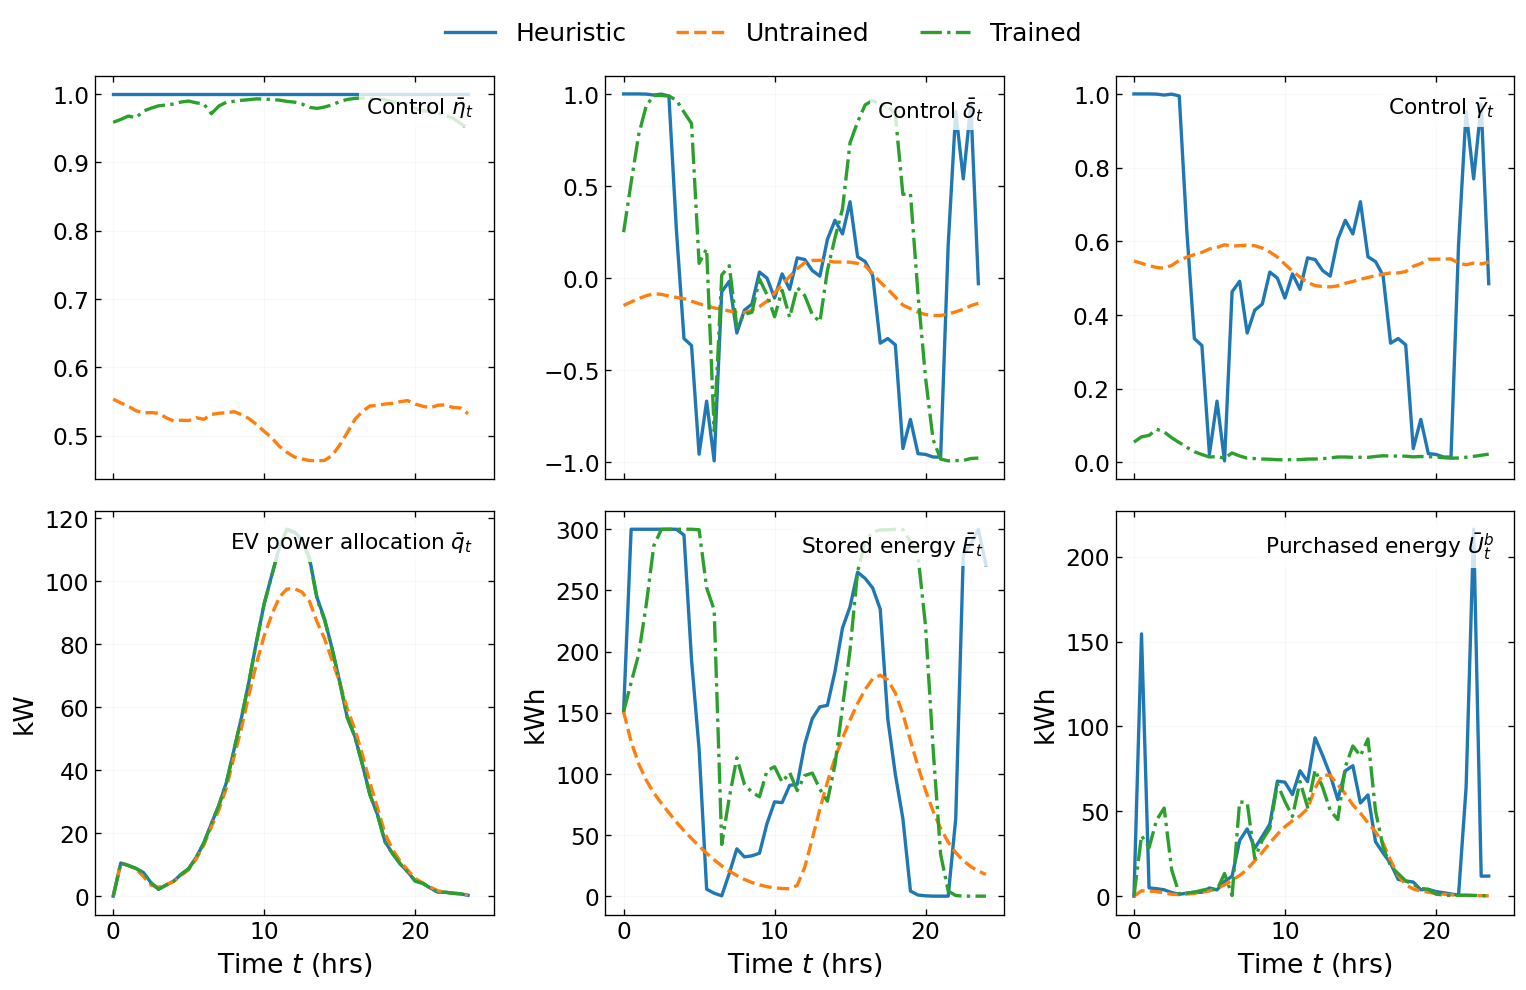

(<Figure size 1560x960 with 6 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='kW'>,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='kWh'>,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='kWh'>], dtype=object))

In [21]:
plot_controls_summary(
    results,
    "../figures/policy_comparison/controls_summary.pdf"
)

In [22]:
from source.utils import summarize_histories

df = summarize_histories(results)
print(df.round(4))

       heuristic  untrained   trained
N         7.6744     7.6744    7.6744
D        27.2015    37.4367   27.2972
E       146.2502    71.8666  166.2162
P         0.0420     0.0420    0.0420
eta       1.0000     0.5220    0.9817
delta     0.0150    -0.0852    0.1299
gamma     0.5075     0.5363    0.0228
q        36.6836    34.0932   36.6204
ec       17.2314     3.5638   14.8669
ed       14.7796     6.2783   17.9436
Ub       34.9422    19.8090   28.8758
Us       14.1485     5.4769   13.6424
A         0.8291     0.8291    0.8291
B         0.7766     0.7766    0.7766
c        -0.1682    -0.1402   -0.5647
J        -8.0739    -6.7277  -27.1034


In [23]:
import os

SAVE_DIR = "../checkpoints/rollouts"
os.makedirs(SAVE_DIR, exist_ok=True)

df = summarize_histories(results)

df.to_csv(
    os.path.join(
        SAVE_DIR,
        "policy_comparison_summary.csv"
    )
)

with open(
    os.path.join(
        SAVE_DIR,
        "policy_comparison_summary.tex"
    ),
    "w"
) as f:
    f.write(df.round(4).to_latex())

print(df.round(4))

       heuristic  untrained   trained
N         7.6744     7.6744    7.6744
D        27.2015    37.4367   27.2972
E       146.2502    71.8666  166.2162
P         0.0420     0.0420    0.0420
eta       1.0000     0.5220    0.9817
delta     0.0150    -0.0852    0.1299
gamma     0.5075     0.5363    0.0228
q        36.6836    34.0932   36.6204
ec       17.2314     3.5638   14.8669
ed       14.7796     6.2783   17.9436
Ub       34.9422    19.8090   28.8758
Us       14.1485     5.4769   13.6424
A         0.8291     0.8291    0.8291
B         0.7766     0.7766    0.7766
c        -0.1682    -0.1402   -0.5647
J        -8.0739    -6.7277  -27.1034
